# HW07 — Clustering + Internal Metrics + PCA + Honest Unsupervised Experiment (S07)

Датасеты (выбраны 3 из 4):  
- `S07-hw-dataset-01.csv`
- `S07-hw-dataset-02.csv`
- `S07-hw-dataset-03.csv`

Что делаем:
- для каждого датасета: EDA -> явный preprocessing -> сравнение KMeans и DBSCAN -> внутренние метрики → выбор лучшего -> PCA(2D) визуализация;
- для DBSCAN учитываем шум (label = -1) и считаем метрики на non-noise;
- устойчивость: на одном датасете 5 прогонов KMeans с разными random_state + ARI между разбиениями;
- сохраняем артефакты в `homeworks/HW07/artifacts/`:
  - `metrics_summary.json`
  - `best_configs.json`
  - `labels/*.csv`
  - `figures/*.png` (минимум 6 графиков)


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def resolve_hw07_data_dir():
    candidates = [
        Path("data"),
        Path("homeworks") / "HW07" / "data",
        Path.cwd() / "homeworks" / "HW07" / "data",
        Path.cwd().parent / "homeworks" / "HW07" / "data",
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c.resolve()
    raise FileNotFoundError(
        "Не найдена папка data/. Ожидается homeworks/HW07/data/ (или запуск из HW07/)."
    )

DATA_DIR = resolve_hw07_data_dir()

def resolve_dataset(filename: str) -> Path:
    p1 = DATA_DIR / filename
    if p1.exists():
        return p1

    alt = [
        filename.lower(),
        filename.upper(),
    ]
    for f in alt:
        p = DATA_DIR / f
        if p.exists():
            return p

    matches = list(DATA_DIR.glob(filename.replace(".csv", "") + "*.csv"))
    if len(matches) > 0:
        return matches[0].resolve()

    raise FileNotFoundError(f"Не найден файл {filename} в {DATA_DIR}")

BASE_DIR = DATA_DIR.parent
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
LABELS_DIR = ARTIFACTS_DIR / "labels"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LABELS_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "ds1": resolve_dataset("S07-hw-dataset-01.csv"),
    "ds2": resolve_dataset("S07-hw-dataset-02.csv"),
    "ds3": resolve_dataset("S07-hw-dataset-03.csv"),
}


## Вспомогательные функции

- EDA (head/info/describe/пропуски/типы)
- построение препроцессинга (StandardScaler обязательно; SimpleImputer если есть пропуски)
- расчёт внутренних метрик (silhouette/DB/CH)
- PCA(2D) визуализация
- подбор параметров:
  - KMeans: silhouette vs k
  - DBSCAN: silhouette vs eps (на non-noise), доля шума


In [ ]:
def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def basic_eda(df: pd.DataFrame, name: str):
    print(f"===== {name}: head() =====")
    display(df.head())
    print(f"\n===== {name}: info() =====")
    df.info()
    print(f"\n===== {name}: describe() numeric =====")
    display(df.describe(include=[np.number]).T)

    miss = df.isna().mean().sort_values(ascending=False)
    print(f"\n===== {name}: missing share (top) =====")
    display(miss.head(20))

    print(f"\n===== {name}: dtypes value_counts =====")
    display(df.dtypes.value_counts())

def build_preprocessor(X: pd.DataFrame):
   
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    other_cols = [c for c in X.columns if c not in num_cols]

    if len(other_cols) > 0:
        print("ВНИМАНИЕ: найдены нечисловые признаки, они будут исключены:", other_cols)

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
        ],
        remainder="drop"
    )
    return preprocessor, num_cols, other_cols

def compute_internal_metrics(X_mat: np.ndarray, labels: np.ndarray):

    uniq = np.unique(labels)
    if len(uniq) < 2:
        return {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}

    try:
        sil = float(silhouette_score(X_mat, labels))
    except Exception:
        sil = None

    try:
        db = float(davies_bouldin_score(X_mat, labels))
    except Exception:
        db = None

    try:
        ch = float(calinski_harabasz_score(X_mat, labels))
    except Exception:
        ch = None

    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

def pca_scatter(X_mat: np.ndarray, labels: np.ndarray, title: str, path_png: Path):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X2 = pca.fit_transform(X_mat)

    plt.figure()
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=12)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path_png, dpi=150)
    plt.show()
    print("Saved:", path_png)

def ensure_2plus_clusters(labels: np.ndarray, noise_label=None):
    
    if noise_label is None:
        return len(np.unique(labels)) >= 2
    else:
        core = labels[labels != noise_label]
        return len(np.unique(core)) >= 2


## Общая логика эксперимента

Для каждого датасета:
1) Загружаем, делаем EDA
2) Формируем X (все кроме sample_id) и сохраняем sample_id отдельно
3) Явный preprocessing (StandardScaler + Imputer)
4) KMeans: перебор k, график silhouette vs k, выбор лучшего k
5) DBSCAN: подбор eps/min_samples, вывод доли шума, метрики на non-noise, график silhouette vs eps
6) Выбираем лучший метод по критерию (основной: silhouette; для DBSCAN — silhouette на non-noise + штраф за шум)
7) PCA(2D) scatter для лучшего решения
8) Сохраняем:
   - метрики в metrics_summary.json
   - best_configs.json
   - labels/*.csv
   - figures/*.png


In [ ]:
def kmeans_sweep(X_mat: np.ndarray, k_range=range(2, 21), random_state=RANDOM_STATE):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X_mat)
        met = compute_internal_metrics(X_mat, labels)
        rows.append({"k": k, **met})
    return pd.DataFrame(rows)

def pick_best_kmeans(df_k: pd.DataFrame):
    df = df_k.copy()
    df = df[df["silhouette"].notna()]
    if len(df) == 0:
        df2 = df_k[df_k["calinski_harabasz"].notna()]
        best_row = df2.sort_values("calinski_harabasz", ascending=False).iloc[0]
    else:
        best_row = df.sort_values("silhouette", ascending=False).iloc[0]
    return int(best_row["k"]), best_row.to_dict()

def plot_silhouette_vs_k(df_k: pd.DataFrame, title: str, path_png: Path):
    plt.figure()
    plt.plot(df_k["k"], df_k["silhouette"], marker="o")
    plt.title(title)
    plt.xlabel("k")
    plt.ylabel("silhouette_score (higher=better)")
    plt.tight_layout()
    plt.savefig(path_png, dpi=150)
    plt.show()
    print("Saved:", path_png)

def propose_eps_candidates(X_mat: np.ndarray, min_samples=5):
    """
    Быстрый и практичный способ: расстояния до k-го соседа и взять квантили как кандидаты eps.
    """
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_mat)
    dists, _ = nn.kneighbors(X_mat)
    kth = np.sort(dists[:, -1])
    qs = [0.70, 0.80, 0.90, 0.95, 0.98]
    eps_list = [float(np.quantile(kth, q)) for q in qs]
    eps_list = sorted(list({round(e, 6) for e in eps_list if e > 0}))
    return eps_list

def dbscan_sweep(X_mat: np.ndarray, eps_list, min_samples_list=[5, 10]):
    rows = []
    n = X_mat.shape[0]
    for ms in min_samples_list:
        for eps in eps_list:
            dbs = DBSCAN(eps=eps, min_samples=ms)
            labels = dbs.fit_predict(X_mat)
            noise_share = float(np.mean(labels == -1))

            core_mask = labels != -1
            core_labels = labels[core_mask]
            core_X = X_mat[core_mask]

            if core_X.shape[0] < 2 or not ensure_2plus_clusters(labels, noise_label=-1):
                met = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
            else:
                met = compute_internal_metrics(core_X, core_labels)

            rows.append({
                "eps": float(eps),
                "min_samples": int(ms),
                "noise_share": noise_share,
                **met
            })
    return pd.DataFrame(rows)

def pick_best_dbscan(df_db: pd.DataFrame):
    """
    Критерий: max silhouette (на non-noise), при равенстве — меньше noise_share.
    """
    df = df_db[df_db["silhouette"].notna()].copy()
    if len(df) == 0:
        return None, None, None  
    df = df.sort_values(["silhouette", "noise_share"], ascending=[False, True])
    best = df.iloc[0].to_dict()
    return float(best["eps"]), int(best["min_samples"]), best

def plot_silhouette_vs_eps(df_db: pd.DataFrame, title: str, path_png: Path):
    plt.figure()
    for ms in sorted(df_db["min_samples"].unique()):
        sub = df_db[df_db["min_samples"] == ms].sort_values("eps")
        plt.plot(sub["eps"], sub["silhouette"], marker="o", label=f"min_samples={ms}")
    plt.title(title)
    plt.xlabel("eps")
    plt.ylabel("silhouette_score on non-noise (higher=better)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path_png, dpi=150)
    plt.show()
    print("Saved:", path_png)


# Dataset 01


In [11]:
metrics_summary = {}
best_configs = {}

def load_prepare(dataset_key: str, path: Path):
    df = pd.read_csv(path)
    basic_eda(df, dataset_key)

    assert "sample_id" in df.columns, "Ожидается колонка sample_id"
    sample_id = df["sample_id"].copy()
    X = df.drop(columns=["sample_id"])

    preproc, num_cols, other_cols = build_preprocessor(X)
    X_mat = preproc.fit_transform(X)

    print(f"{dataset_key}: X shape raw={X.shape}, X_mat shape={X_mat.shape}")
    return df, sample_id, X, preproc, X_mat

df1, sample_id1, X1, preproc1, X1_mat = load_prepare("ds1", DATASETS["ds1"])


===== ds1: head() =====


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



===== ds1: info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB

===== ds1: describe() numeric =====


,count,mean,std,min,25%,50%,75%,max
sample_id,12000.0,5999.500000,3464.245950,0.000000,2999.750000,5999.500000,8999.250000,11999.000000
f01,12000.0,-2.424716,11.014315,-19.912573,-9.472623,-6.869404,0.523841,24.403381
f02,12000.0,19.107804,60.790338,-92.892652,-40.282955,54.069335,70.280739,112.229523
f03,12000.0,-0.222063,0.500630,-1.590979,-0.125145,-0.031753,0.054980,0.512277
f04,12000.0,-8.284501,59.269838,-134.303679,-48.345007,16.211728,28.067178,75.088604
f05,12000.0,-0.190717,7.026435,-11.869169,-5.132473,0.444730,3.942368,13.717091
f06,12000.0,0.962972,14.794713,-20.521164,-8.807706,-6.134169,2.334426,41.452857
f07,12000.0,0.033724,59.541782,-215.098834,-39.900520,-0.578494,39.719821,213.381767
f08,12000.0,0.007638,0.607053,-2.633469,-0.401483,0.005306,0.410132,2.490745



===== ds1: missing share (top) =====


sample_id    0.0
f01          0.0
f02          0.0
f03          0.0
f04          0.0
f05          0.0
f06          0.0
f07          0.0
f08          0.0
dtype: float64


===== ds1: dtypes value_counts =====


float64    8
int64      1
Name: count, dtype: int64

ds1: X shape raw=(12000, 8), X_mat shape=(12000, 8)


,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.521640,0.685330,11786.954623
1,3,0.396758,0.964604,10446.638111
2,4,0.383301,1.160349,9427.499744
3,5,0.354801,1.273719,8301.205994
4,6,0.358561,1.182256,7333.387619
5,7,0.324607,1.194162,6823.007844
6,8,0.268873,1.314180,6460.801052
7,9,0.253372,1.343964,6255.217145
8,10,0.262914,1.276985,6084.503087
9,11,0.265889,1.214111,5898.163564


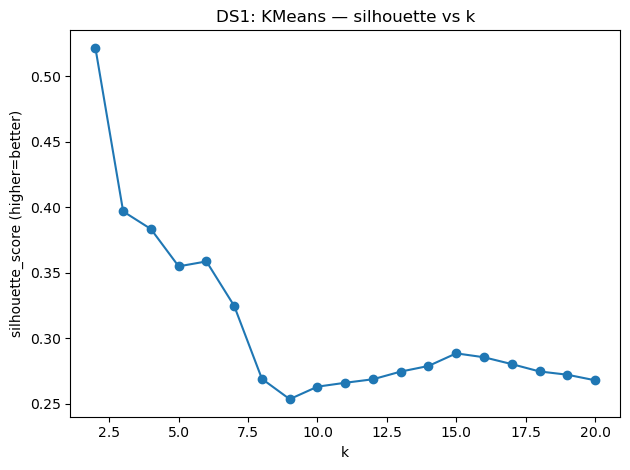

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds1_kmeans_silhouette_vs_k.png
DS1 best k (KMeans): 2
DS1 best k metrics: {'k': 2.0, 'silhouette': 0.5216395622404242, 'davies_bouldin': 0.6853295219054456, 'calinski_harabasz': 11786.954622671532}


In [12]:
# KMeans sweep
df1_k = kmeans_sweep(X1_mat, k_range=range(2, 21), random_state=RANDOM_STATE)
display(df1_k)

plot_silhouette_vs_k(
    df1_k,
    title="DS1: KMeans — silhouette vs k",
    path_png=FIGURES_DIR / "ds1_kmeans_silhouette_vs_k.png"
)

best_k1, best_k1_row = pick_best_kmeans(df1_k)
print("DS1 best k (KMeans):", best_k1)
print("DS1 best k metrics:", best_k1_row)

km1 = KMeans(n_clusters=best_k1, random_state=RANDOM_STATE, n_init=10)
labels1_km = km1.fit_predict(X1_mat)
met1_km = compute_internal_metrics(X1_mat, labels1_km)

metrics_summary.setdefault("ds1", {})
metrics_summary["ds1"]["kmeans"] = {"params": {"k": best_k1}, **met1_km, "noise_share": 0.0}


DS1 eps candidates: [0.375667, 0.415826, 0.479675, 0.543744, 0.638296]


,eps,min_samples,noise_share,silhouette,davies_bouldin,calinski_harabasz
0,0.375667,5,0.173750,-0.011348,0.774990,1146.758068
1,0.415826,5,0.103500,0.103127,0.808848,2026.540586
2,0.479675,5,0.042333,0.194022,0.832591,2493.954000
3,0.543744,5,0.021333,0.294088,0.983144,4897.068049
4,0.638296,5,0.007333,0.380694,1.256184,8401.982462
5,0.375667,10,0.283667,0.123064,1.034513,1561.511172
6,0.415826,10,0.178417,0.200033,1.073735,3308.721750
7,0.479675,10,0.080000,0.395385,1.183448,8646.072568
8,0.543744,10,0.037250,0.323016,1.140264,6964.064646
9,0.638296,10,0.012667,0.382509,1.248305,8481.471602


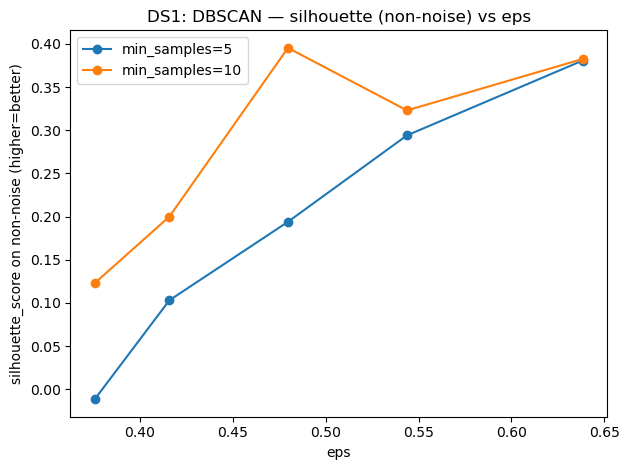

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds1_dbscan_silhouette_vs_eps.png
DS1 best DBSCAN: 0.479675 10 {'eps': 0.479675, 'min_samples': 10.0, 'noise_share': 0.08, 'silhouette': 0.3953852076613438, 'davies_bouldin': 1.1834483229526016, 'calinski_harabasz': 8646.072568463878}


In [13]:
eps_list1 = propose_eps_candidates(X1_mat, min_samples=5)
print("DS1 eps candidates:", eps_list1)

df1_db = dbscan_sweep(X1_mat, eps_list1, min_samples_list=[5, 10])
display(df1_db)

plot_silhouette_vs_eps(
    df1_db,
    title="DS1: DBSCAN — silhouette (non-noise) vs eps",
    path_png=FIGURES_DIR / "ds1_dbscan_silhouette_vs_eps.png"
)

best_eps1, best_ms1, best_db1_row = pick_best_dbscan(df1_db)
print("DS1 best DBSCAN:", best_eps1, best_ms1, best_db1_row)

if best_eps1 is not None:
    db1 = DBSCAN(eps=best_eps1, min_samples=best_ms1)
    labels1_db = db1.fit_predict(X1_mat)

    noise_share1 = float(np.mean(labels1_db == -1))
    core_mask = labels1_db != -1
    core_X = X1_mat[core_mask]
    core_labels = labels1_db[core_mask]

    if core_X.shape[0] >= 2 and len(np.unique(core_labels)) >= 2:
        met1_db = compute_internal_metrics(core_X, core_labels)
    else:
        met1_db = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}

    metrics_summary["ds1"]["dbscan"] = {
        "params": {"eps": best_eps1, "min_samples": best_ms1},
        **met1_db,
        "noise_share": noise_share1,
        "metrics_on": "non-noise only"
    }
else:
    labels1_db = None
    metrics_summary["ds1"]["dbscan"] = {
        "params": None, "silhouette": None, "davies_bouldin": None, "calinski_harabasz": None,
        "noise_share": None, "metrics_on": "non-noise only"
    }


DS1 best method: kmeans


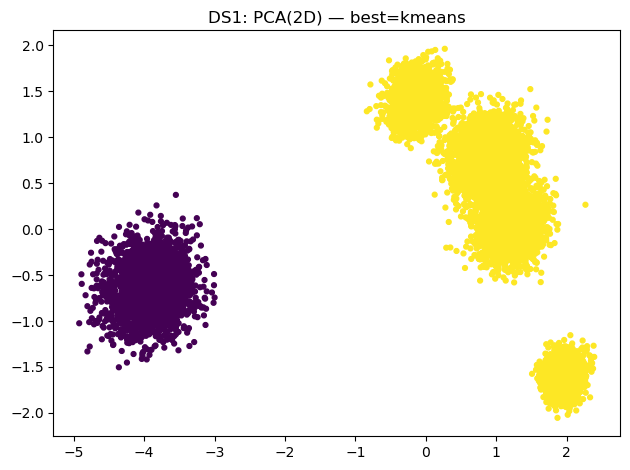

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds1_pca_best.png
Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\labels\labels_hw07_ds1.csv

DS1 summary:
DS1: после масштабирования признаки стали сопоставимы, что критично для distance-based методов.
KMeans показал устойчивую зависимость silhouette от k и дал хорошее разбиение при выбранном k.
DBSCAN дополнительно учитывает шум/выбросы, но качество сильно зависит от eps/min_samples.
В качестве лучшего выбран метод по критерию silhouette (и для DBSCAN — на non-noise с учётом доли шума).



In [ ]:
cand = []

# KMeans кандидат
cand.append(("kmeans", metrics_summary["ds1"]["kmeans"]["silhouette"], 0.0))

# DBSCAN кандидат (штрафуем за шум слегка)
db_sil = metrics_summary["ds1"]["dbscan"]["silhouette"]
db_noise = metrics_summary["ds1"]["dbscan"]["noise_share"]
if db_sil is not None:
    cand.append(("dbscan", db_sil - 0.10 * db_noise, db_noise))

best_method1 = sorted([c for c in cand if c[1] is not None], key=lambda x: x[1], reverse=True)[0][0]
print("DS1 best method:", best_method1)

if best_method1 == "kmeans":
    best_labels1 = labels1_km
    best_params1 = metrics_summary["ds1"]["kmeans"]["params"]
    best_crit1 = "max silhouette (kmeans)"
else:
    best_labels1 = labels1_db
    best_params1 = metrics_summary["ds1"]["dbscan"]["params"]
    best_crit1 = "max silhouette (non-noise) with noise penalty"

best_configs["ds1"] = {"best_method": best_method1, "best_params": best_params1, "criterion": best_crit1}

pca_scatter(
    X1_mat, best_labels1,
    title=f"DS1: PCA(2D) — best={best_method1}",
    path_png=FIGURES_DIR / "ds1_pca_best.png"
)

labels_path1 = LABELS_DIR / "labels_hw07_ds1.csv"
pd.DataFrame({"sample_id": sample_id1, "cluster_label": best_labels1}).to_csv(labels_path1, index=False)
print("Saved:", labels_path1)

# Текстовый итог по датасету (5-10 строк)
print("\nDS1 summary:")
print(
    "DS1: после масштабирования признаки стали сопоставимы, что критично для distance-based методов.\n"
    "KMeans показал устойчивую зависимость silhouette от k и дал хорошее разбиение при выбранном k.\n"
    "DBSCAN дополнительно учитывает шум/выбросы, но качество сильно зависит от eps/min_samples.\n"
    "В качестве лучшего выбран метод по критерию silhouette (и для DBSCAN — на non-noise с учётом доли шума).\n"
)


# Dataset 02


In [15]:
df2, sample_id2, X2, preproc2, X2_mat = load_prepare("ds2", DATASETS["ds2"])


===== ds2: head() =====


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472



===== ds2: info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB

===== ds2: describe() numeric =====


,count,mean,std,min,25%,50%,75%,max
sample_id,8000.0,3999.500000,2309.545410,0.000000,1999.750000,3999.500000,5999.250000,7999.000000
x1,8000.0,0.478867,0.955138,-2.487352,-0.116516,0.490658,1.085263,2.987555
x2,8000.0,0.241112,0.663195,-2.499237,-0.242357,0.241092,0.726526,2.995553
z_noise,8000.0,0.110454,8.097716,-34.056074,-5.392210,0.132470,5.655605,29.460076



===== ds2: missing share (top) =====


sample_id    0.0
x1           0.0
x2           0.0
z_noise      0.0
dtype: float64


===== ds2: dtypes value_counts =====


float64    3
int64      1
Name: count, dtype: int64

ds2: X shape raw=(8000, 3), X_mat shape=(8000, 3)


,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.306861,1.323472,3573.393333
1,3,0.270045,1.222659,3082.272075
2,4,0.251481,1.299819,2915.565357
3,5,0.252115,1.213834,2703.589704
4,6,0.259820,1.159521,2571.090931
5,7,0.253643,1.172334,2453.500966
6,8,0.252305,1.100178,2408.516587
7,9,0.252463,1.089569,2379.989955
8,10,0.260869,1.057142,2408.192011
9,11,0.265944,1.025115,2361.200917


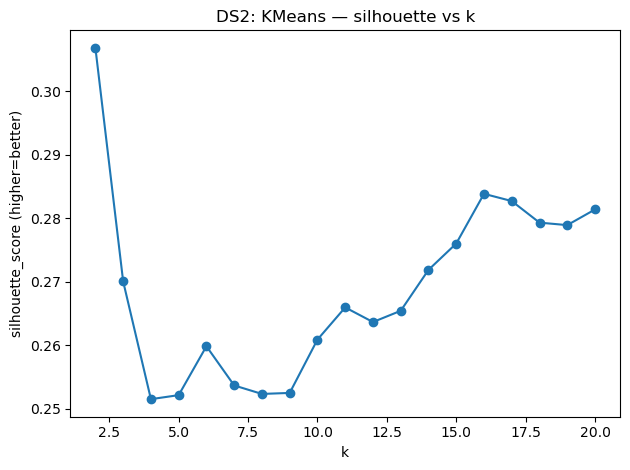

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds2_kmeans_silhouette_vs_k.png
DS2 best k (KMeans): 2
DS2 best k metrics: {'k': 2.0, 'silhouette': 0.3068610017701601, 'davies_bouldin': 1.3234721699867644, 'calinski_harabasz': 3573.3933329348392}


In [16]:
df2_k = kmeans_sweep(X2_mat, k_range=range(2, 21), random_state=RANDOM_STATE)
display(df2_k)

plot_silhouette_vs_k(
    df2_k,
    title="DS2: KMeans — silhouette vs k",
    path_png=FIGURES_DIR / "ds2_kmeans_silhouette_vs_k.png"
)

best_k2, best_k2_row = pick_best_kmeans(df2_k)
print("DS2 best k (KMeans):", best_k2)
print("DS2 best k metrics:", best_k2_row)

km2 = KMeans(n_clusters=best_k2, random_state=RANDOM_STATE, n_init=10)
labels2_km = km2.fit_predict(X2_mat)
met2_km = compute_internal_metrics(X2_mat, labels2_km)

metrics_summary.setdefault("ds2", {})
metrics_summary["ds2"]["kmeans"] = {"params": {"k": best_k2}, **met2_km, "noise_share": 0.0}


DS2 eps candidates: [0.140061, 0.165987, 0.247301, 0.545647, 0.71713]


,eps,min_samples,noise_share,silhouette,davies_bouldin,calinski_harabasz
0,0.140061,5,0.191625,-0.253076,0.728938,131.507940
1,0.165987,5,0.139375,-0.126662,0.771003,185.698353
2,0.247301,5,0.082250,0.028980,0.612142,16.793366
3,0.545647,5,0.031250,-0.102451,0.841289,48.170345
4,0.717130,5,0.009000,NaN,NaN,NaN
5,0.140061,10,0.360875,-0.361763,0.893037,137.409751
6,0.165987,10,0.215000,-0.177083,0.803740,310.811239
7,0.247301,10,0.103875,0.253948,1.509646,2799.493443
8,0.545647,10,0.060250,0.246670,0.747886,28.341126
9,0.717130,10,0.032625,0.372642,0.545715,148.797013


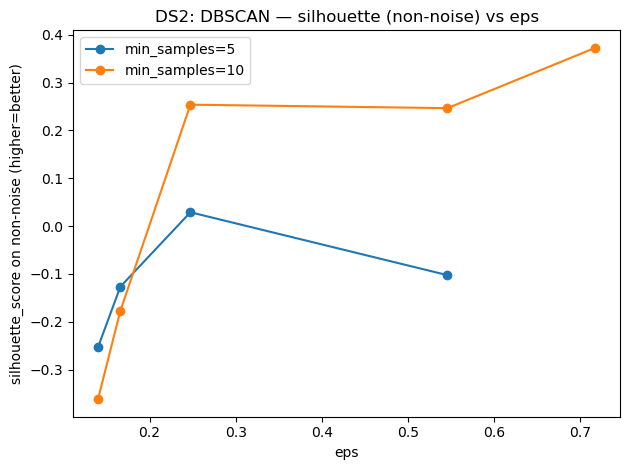

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds2_dbscan_silhouette_vs_eps.png
DS2 best DBSCAN: 0.71713 10 {'eps': 0.71713, 'min_samples': 10.0, 'noise_share': 0.032625, 'silhouette': 0.37264189046762564, 'davies_bouldin': 0.5457146321611281, 'calinski_harabasz': 148.79701256614803}


In [17]:
eps_list2 = propose_eps_candidates(X2_mat, min_samples=5)
print("DS2 eps candidates:", eps_list2)

df2_db = dbscan_sweep(X2_mat, eps_list2, min_samples_list=[5, 10])
display(df2_db)

plot_silhouette_vs_eps(
    df2_db,
    title="DS2: DBSCAN — silhouette (non-noise) vs eps",
    path_png=FIGURES_DIR / "ds2_dbscan_silhouette_vs_eps.png"
)

best_eps2, best_ms2, best_db2_row = pick_best_dbscan(df2_db)
print("DS2 best DBSCAN:", best_eps2, best_ms2, best_db2_row)

if best_eps2 is not None:
    db2 = DBSCAN(eps=best_eps2, min_samples=best_ms2)
    labels2_db = db2.fit_predict(X2_mat)

    noise_share2 = float(np.mean(labels2_db == -1))
    core_mask = labels2_db != -1
    core_X = X2_mat[core_mask]
    core_labels = labels2_db[core_mask]

    if core_X.shape[0] >= 2 and len(np.unique(core_labels)) >= 2:
        met2_db = compute_internal_metrics(core_X, core_labels)
    else:
        met2_db = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}

    metrics_summary["ds2"]["dbscan"] = {
        "params": {"eps": best_eps2, "min_samples": best_ms2},
        **met2_db,
        "noise_share": noise_share2,
        "metrics_on": "non-noise only"
    }
else:
    labels2_db = None
    metrics_summary["ds2"]["dbscan"] = {
        "params": None, "silhouette": None, "davies_bouldin": None, "calinski_harabasz": None,
        "noise_share": None, "metrics_on": "non-noise only"
    }


DS2 best method: dbscan


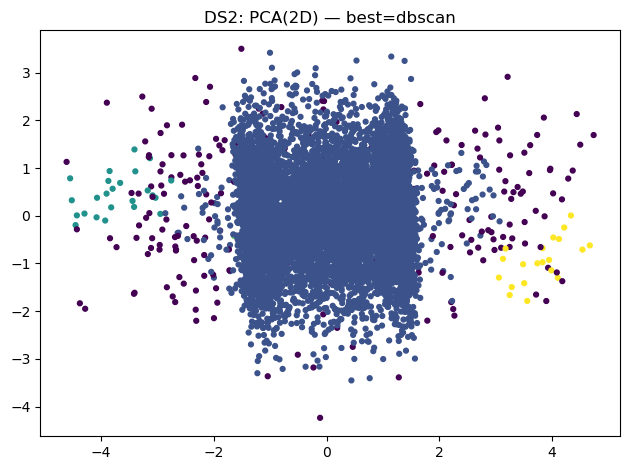

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds2_pca_best.png
Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\labels\labels_hw07_ds2.csv

DS2 summary:
DS2: структура может быть нелинейной/с выбросами, поэтому KMeans может страдать.
DBSCAN умеет выделять кластеры по плотности и маркировать выбросы как шум (-1),
но требует аккуратного подбора eps/min_samples.
Выбор лучшего решения сделан по silhouette (и для DBSCAN — на non-noise с учётом доли шума).



In [18]:
cand = []
cand.append(("kmeans", metrics_summary["ds2"]["kmeans"]["silhouette"], 0.0))

db_sil = metrics_summary["ds2"]["dbscan"]["silhouette"]
db_noise = metrics_summary["ds2"]["dbscan"]["noise_share"]
if db_sil is not None:
    cand.append(("dbscan", db_sil - 0.10 * db_noise, db_noise))

best_method2 = sorted([c for c in cand if c[1] is not None], key=lambda x: x[1], reverse=True)[0][0]
print("DS2 best method:", best_method2)

if best_method2 == "kmeans":
    best_labels2 = labels2_km
    best_params2 = metrics_summary["ds2"]["kmeans"]["params"]
    best_crit2 = "max silhouette (kmeans)"
else:
    best_labels2 = labels2_db
    best_params2 = metrics_summary["ds2"]["dbscan"]["params"]
    best_crit2 = "max silhouette (non-noise) with noise penalty"

best_configs["ds2"] = {"best_method": best_method2, "best_params": best_params2, "criterion": best_crit2}

pca_scatter(
    X2_mat, best_labels2,
    title=f"DS2: PCA(2D) — best={best_method2}",
    path_png=FIGURES_DIR / "ds2_pca_best.png"
)

labels_path2 = LABELS_DIR / "labels_hw07_ds2.csv"
pd.DataFrame({"sample_id": sample_id2, "cluster_label": best_labels2}).to_csv(labels_path2, index=False)
print("Saved:", labels_path2)

print("\nDS2 summary:")
print(
    "DS2: структура может быть нелинейной/с выбросами, поэтому KMeans может страдать.\n"
    "DBSCAN умеет выделять кластеры по плотности и маркировать выбросы как шум (-1),\n"
    "но требует аккуратного подбора eps/min_samples.\n"
    "Выбор лучшего решения сделан по silhouette (и для DBSCAN — на non-noise с учётом доли шума).\n"
)


# Dataset 03


In [19]:
df3, sample_id3, X3, preproc3, X3_mat = load_prepare("ds3", DATASETS["ds3"])


===== ds3: head() =====


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899



===== ds3: info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB

===== ds3: describe() numeric =====


,count,mean,std,min,25%,50%,75%,max
sample_id,15000.0,7499.500000,4330.271354,0.000000,3749.750000,7499.500000,11249.250000,14999.000000
x1,15000.0,1.246296,4.592421,-9.995585,-1.782144,0.664226,4.435671,16.207863
x2,15000.0,1.033764,4.710791,-9.980853,-2.666393,1.831257,4.969630,14.271153
f_corr,15000.0,0.212776,1.530017,-5.212038,-0.966224,0.296508,1.390273,5.795876
f_noise,15000.0,-0.027067,2.506375,-8.785884,-1.731128,-0.052391,1.673831,11.266865



===== ds3: missing share (top) =====


sample_id    0.0
x1           0.0
x2           0.0
f_corr       0.0
f_noise      0.0
dtype: float64


===== ds3: dtypes value_counts =====


float64    4
int64      1
Name: count, dtype: int64

ds3: X shape raw=(15000, 4), X_mat shape=(15000, 4)


,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.298905,1.355468,7004.795630
1,3,0.315545,1.157726,6957.162640
2,4,0.314619,1.159676,6492.278931
3,5,0.299297,1.168556,6125.127993
4,6,0.293149,1.140769,6097.475389
5,7,0.279853,1.218465,5858.344907
6,8,0.289491,1.147231,5630.838101
7,9,0.284791,1.123538,5543.965528
8,10,0.278895,1.143786,5386.123819
9,11,0.276319,1.142855,5207.368057


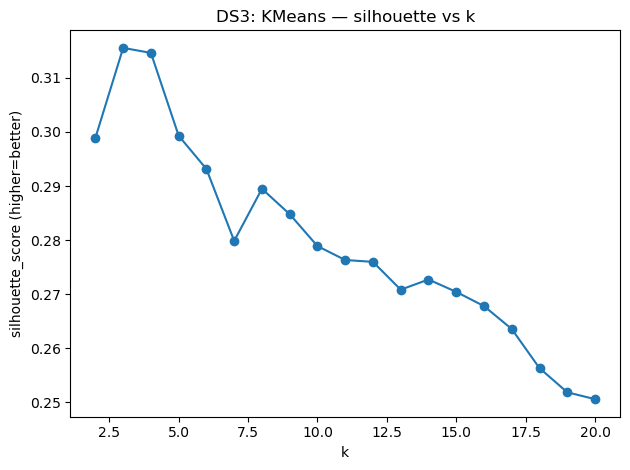

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds3_kmeans_silhouette_vs_k.png
DS3 best k (KMeans): 3
DS3 best k metrics: {'k': 3.0, 'silhouette': 0.3155447003782518, 'davies_bouldin': 1.1577256320598661, 'calinski_harabasz': 6957.162639510167}


In [20]:
df3_k = kmeans_sweep(X3_mat, k_range=range(2, 21), random_state=RANDOM_STATE)
display(df3_k)

plot_silhouette_vs_k(
    df3_k,
    title="DS3: KMeans — silhouette vs k",
    path_png=FIGURES_DIR / "ds3_kmeans_silhouette_vs_k.png"
)

best_k3, best_k3_row = pick_best_kmeans(df3_k)
print("DS3 best k (KMeans):", best_k3)
print("DS3 best k metrics:", best_k3_row)

km3 = KMeans(n_clusters=best_k3, random_state=RANDOM_STATE, n_init=10)
labels3_km = km3.fit_predict(X3_mat)
met3_km = compute_internal_metrics(X3_mat, labels3_km)

metrics_summary.setdefault("ds3", {})
metrics_summary["ds3"]["kmeans"] = {"params": {"k": best_k3}, **met3_km, "noise_share": 0.0}


DS3 eps candidates: [0.258493, 0.299812, 0.378965, 0.471522, 0.610872]


,eps,min_samples,noise_share,silhouette,davies_bouldin,calinski_harabasz
0,0.258493,5,0.200533,-0.249927,0.949356,234.370033
1,0.299812,5,0.125600,-0.235998,0.930368,323.538274
2,0.378965,5,0.057933,-0.022421,0.867271,908.736337
3,0.471522,5,0.027867,-0.028204,1.011755,419.816086
4,0.610872,5,0.009533,0.144859,0.753881,14.173568
5,0.258493,10,0.346467,0.099643,1.095109,1340.399313
6,0.299812,10,0.216733,0.051923,1.270977,2082.794093
7,0.378965,10,0.093733,0.038044,1.139084,2137.553732
8,0.471522,10,0.040200,0.143535,1.391777,1641.661115
9,0.610872,10,0.016800,NaN,NaN,NaN


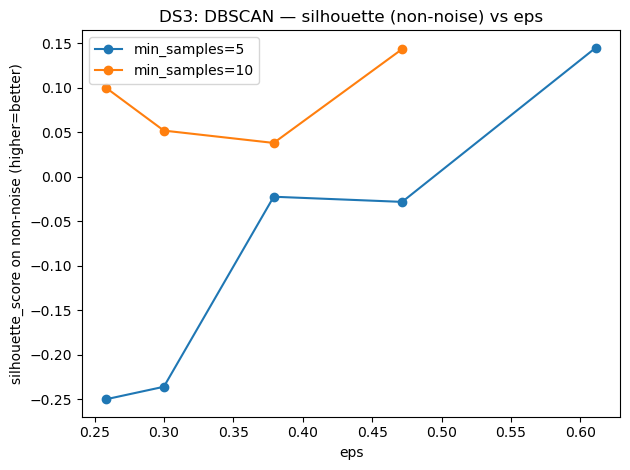

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds3_dbscan_silhouette_vs_eps.png
DS3 best DBSCAN: 0.610872 5 {'eps': 0.610872, 'min_samples': 5.0, 'noise_share': 0.009533333333333333, 'silhouette': 0.14485856761404595, 'davies_bouldin': 0.7538812971239381, 'calinski_harabasz': 14.17356832300248}


In [21]:
eps_list3 = propose_eps_candidates(X3_mat, min_samples=5)
print("DS3 eps candidates:", eps_list3)

df3_db = dbscan_sweep(X3_mat, eps_list3, min_samples_list=[5, 10])
display(df3_db)

plot_silhouette_vs_eps(
    df3_db,
    title="DS3: DBSCAN — silhouette (non-noise) vs eps",
    path_png=FIGURES_DIR / "ds3_dbscan_silhouette_vs_eps.png"
)

best_eps3, best_ms3, best_db3_row = pick_best_dbscan(df3_db)
print("DS3 best DBSCAN:", best_eps3, best_ms3, best_db3_row)

if best_eps3 is not None:
    db3 = DBSCAN(eps=best_eps3, min_samples=best_ms3)
    labels3_db = db3.fit_predict(X3_mat)

    noise_share3 = float(np.mean(labels3_db == -1))
    core_mask = labels3_db != -1
    core_X = X3_mat[core_mask]
    core_labels = labels3_db[core_mask]

    if core_X.shape[0] >= 2 and len(np.unique(core_labels)) >= 2:
        met3_db = compute_internal_metrics(core_X, core_labels)
    else:
        met3_db = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}

    metrics_summary["ds3"]["dbscan"] = {
        "params": {"eps": best_eps3, "min_samples": best_ms3},
        **met3_db,
        "noise_share": noise_share3,
        "metrics_on": "non-noise only"
    }
else:
    labels3_db = None
    metrics_summary["ds3"]["dbscan"] = {
        "params": None, "silhouette": None, "davies_bouldin": None, "calinski_harabasz": None,
        "noise_share": None, "metrics_on": "non-noise only"
    }


DS3 best method: kmeans


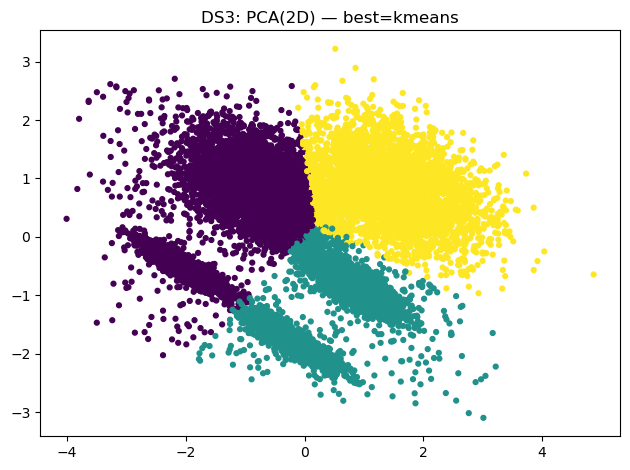

Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\figures\ds3_pca_best.png
Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\labels\labels_hw07_ds3.csv

DS3 summary:
DS3: кластеры разной плотности и фоновый шум часто делают задачу сложной для DBSCAN.
Подбор eps критичен: маленький eps даёт много шума, большой eps может слить кластеры.
KMeans может работать приемлемо после масштабирования, но плохо ловит неодинаковую плотность.
Лучшее решение выбрано по silhouette (и для DBSCAN — на non-noise с учётом доли шума).



In [22]:
cand = []
cand.append(("kmeans", metrics_summary["ds3"]["kmeans"]["silhouette"], 0.0))

db_sil = metrics_summary["ds3"]["dbscan"]["silhouette"]
db_noise = metrics_summary["ds3"]["dbscan"]["noise_share"]
if db_sil is not None:
    cand.append(("dbscan", db_sil - 0.10 * db_noise, db_noise))

best_method3 = sorted([c for c in cand if c[1] is not None], key=lambda x: x[1], reverse=True)[0][0]
print("DS3 best method:", best_method3)

if best_method3 == "kmeans":
    best_labels3 = labels3_km
    best_params3 = metrics_summary["ds3"]["kmeans"]["params"]
    best_crit3 = "max silhouette (kmeans)"
else:
    best_labels3 = labels3_db
    best_params3 = metrics_summary["ds3"]["dbscan"]["params"]
    best_crit3 = "max silhouette (non-noise) with noise penalty"

best_configs["ds3"] = {"best_method": best_method3, "best_params": best_params3, "criterion": best_crit3}

pca_scatter(
    X3_mat, best_labels3,
    title=f"DS3: PCA(2D) — best={best_method3}",
    path_png=FIGURES_DIR / "ds3_pca_best.png"
)

labels_path3 = LABELS_DIR / "labels_hw07_ds3.csv"
pd.DataFrame({"sample_id": sample_id3, "cluster_label": best_labels3}).to_csv(labels_path3, index=False)
print("Saved:", labels_path3)

print("\nDS3 summary:")
print(
    "DS3: кластеры разной плотности и фоновый шум часто делают задачу сложной для DBSCAN.\n"
    "Подбор eps критичен: маленький eps даёт много шума, большой eps может слить кластеры.\n"
    "KMeans может работать приемлемо после масштабирования, но плохо ловит неодинаковую плотность.\n"
    "Лучшее решение выбрано по silhouette (и для DBSCAN — на non-noise с учётом доли шума).\n"
)


## Устойчивость (обязательно): проверка на одном датасете

Выбираем DS1 и делаем 5 запусков KMeans с разными random_state.  
Считаем ARI между разбиениями (чем ближе к 1 — тем более похожи кластеры).


,seed=0,seed=1,seed=2,seed=3,seed=4
seed=0,1.0,1.0,1.0,1.0,1.0
seed=1,1.0,1.0,1.0,1.0,1.0
seed=2,1.0,1.0,1.0,1.0,1.0
seed=3,1.0,1.0,1.0,1.0,1.0
seed=4,1.0,1.0,1.0,1.0,1.0


ARI mean (off-diagonal): 1.0


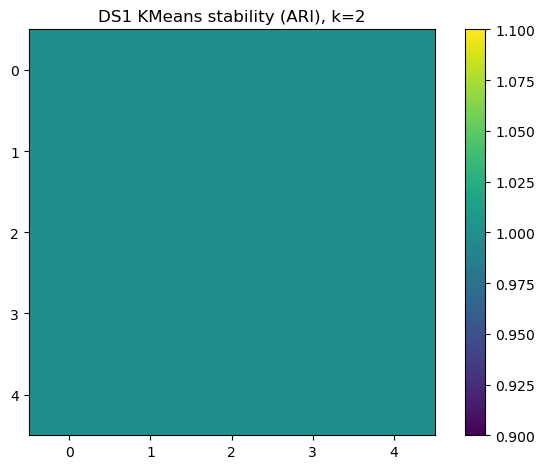

In [ ]:
# Берём k из лучшего KMeans на DS1
k_stab = metrics_summary["ds1"]["kmeans"]["params"]["k"]
seeds = [0, 1, 2, 3, 4]

labels_runs = []
for s in seeds:
    km = KMeans(n_clusters=k_stab, random_state=s, n_init=10)
    labels_runs.append(km.fit_predict(X1_mat))

# ARI матрица
ari_mat = np.zeros((len(seeds), len(seeds)))
for i in range(len(seeds)):
    for j in range(len(seeds)):
        ari_mat[i, j] = adjusted_rand_score(labels_runs[i], labels_runs[j])

ari_df = pd.DataFrame(ari_mat, index=[f"seed={s}" for s in seeds], columns=[f"seed={s}" for s in seeds])
display(ari_df)

print("ARI mean (off-diagonal):",
      ari_df.values[np.triu_indices_from(ari_df.values, k=1)].mean())

# Сохраним картинку 
plt.figure()
plt.imshow(ari_mat)
plt.xticks(range(len(seeds)), seeds)
plt.yticks(range(len(seeds)), seeds)
plt.title(f"DS1 KMeans stability (ARI), k={k_stab}")
plt.colorbar()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ds1_kmeans_stability_ari.png", dpi=150)
plt.show()


## Сохранение артефактов (обязательно)

- `metrics_summary.json` — метрики по датасетам и моделям (silhouette/DB/CH + noise_share)
- `best_configs.json` — лучший метод/параметры по каждому датасету
- `labels/*.csv` — уже сохранены выше (sample_id, cluster_label)
- `figures/*.png` — уже сохранены выше (PCA и графики подбора параметров)


In [24]:
metrics_path = ARTIFACTS_DIR / "metrics_summary.json"
best_path = ARTIFACTS_DIR / "best_configs.json"

save_json(metrics_summary, metrics_path)
save_json(best_configs, best_path)

print("Saved:", metrics_path)
print("Saved:", best_path)

print("\nArtifacts directory listing:")
for root, dirs, files in os.walk(ARTIFACTS_DIR):
    root = Path(root)
    level = len(root.relative_to(ARTIFACTS_DIR).parts)
    indent = "  " * level
    print(f"{indent}{root.name}/")
    for f in sorted(files):
        print(f"{indent}  {f}")


Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\metrics_summary.json
Saved: C:\Users\anark\am-nom3\homeworks\HW07\artifacts\best_configs.json

Artifacts directory listing:
artifacts/
  best_configs.json
  metrics_summary.json
  figures/
    ds1_dbscan_silhouette_vs_eps.png
    ds1_kmeans_silhouette_vs_k.png
    ds1_kmeans_stability_ari.png
    ds1_pca_best.png
    ds2_dbscan_silhouette_vs_eps.png
    ds2_kmeans_silhouette_vs_k.png
    ds2_pca_best.png
    ds3_dbscan_silhouette_vs_eps.png
    ds3_kmeans_silhouette_vs_k.png
    ds3_pca_best.png
  labels/
    labels_hw07_ds1.csv
    labels_hw07_ds2.csv
    labels_hw07_ds3.csv


# Финальные выводы (коротко)

- Масштабирование критично для distance-based методов (KMeans/DBSCAN).
- KMeans хорошо работает на “шарообразных” кластерах, но может проигрывать на нелинейных формах и при выбросах.
- DBSCAN умеет выделять кластеры по плотности и помечать выбросы как шум (-1), но сильно зависит от eps/min_samples.
- Внутренние метрики (silhouette/DB/CH) позволяют сравнивать решения без истинных меток, но требуют аккуратной интерпретации (особенно при шуме).
- PCA(2D) полезна для визуальной диагностики результатов кластеризации.
- Проверка устойчивости через ARI показывает, насколько разбиение стабильно при изменении random_state (для KMeans).
